# Problem 1

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Reproducibility
SEED = 1

# Problem 1 parameters
N = 5
p = 0.5

# Generate Erdős-Rényi random undirected graph
G1 = nx.erdos_renyi_graph(N, p, seed=SEED)

print("Number of nodes:", G1.number_of_nodes())
print("Number of edges:", G1.number_of_edges())
print("Edges:", list(G1.edges()))

Number of nodes: 5
Number of edges: 6
Edges: [(0, 1), (0, 4), (1, 2), (1, 3), (2, 4), (3, 4)]


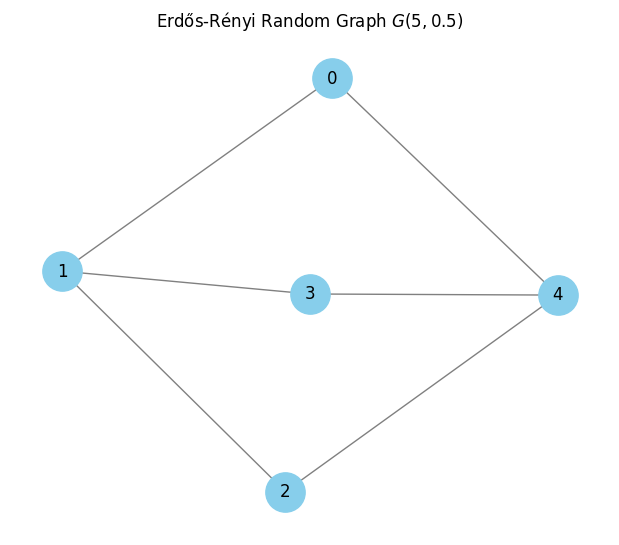

In [ ]:
plt.figure(figsize=(6, 5))

pos = nx.spring_layout(G1, seed=SEED)

nx.draw(
    G1,
    pos,
    with_labels=True,
    node_size=800,
    node_color="skyblue",
    edge_color="gray",
    font_size=12
)

plt.title(r"Erdős-Rényi Random Graph $G(5,0.5)$")
plt.axis("off")
plt.show()

## Problem 1(a): Graph Matrices

In [ ]:
# Adjacency matrix
A = nx.to_numpy_array(G1, dtype=int)

# Degree matrix
degrees = np.array([G1.degree(i) for i in G1.nodes()])
D = np.diag(degrees)

# Laplacian matrix
L = D - A

# Incidence matrix
# Arbitrary orientation: first node = +1, second node = -1
edges = list(G1.edges())

B = np.zeros((N, len(edges)), dtype=int)

for j, (u, v) in enumerate(edges):
    B[u, j] = 1
    B[v, j] = -1

print("Adjacency Matrix A:")
print(A)

print("\nDegree Matrix D:")
print(D)

print("\nIncidence Matrix B:")
print(B)

print("\nLaplacian Matrix L:")
print(L)

Adjacency Matrix A:
[[0 1 0 0 1]
 [1 0 1 1 0]
 [0 1 0 0 1]
 [0 1 0 0 1]
 [1 0 1 1 0]]

Degree Matrix D:
[[2 0 0 0 0]
 [0 3 0 0 0]
 [0 0 2 0 0]
 [0 0 0 2 0]
 [0 0 0 0 3]]

Incidence Matrix B:
[[ 1  1  0  0  0  0]
 [-1  0  1  1  0  0]
 [ 0  0 -1  0  1  0]
 [ 0  0  0 -1  0  1]
 [ 0 -1  0  0 -1 -1]]

Laplacian Matrix L:
[[ 2 -1  0  0 -1]
 [-1  3 -1 -1  0]
 [ 0 -1  2  0 -1]
 [ 0 -1  0  2 -1]
 [-1  0 -1 -1  3]]


## Problem 1(b): Laplacian Eigenvalues and Algebraic Connectivity

In [ ]:
# Compute Laplacian eigenvalues
eigenvalues = np.linalg.eigvalsh(L)

# Sort eigenvalues
eigenvalues = np.sort(eigenvalues)

# Algebraic connectivity
lambda_2 = eigenvalues[1]

print("Laplacian eigenvalues:")
print(eigenvalues)

print("\nAlgebraic connectivity (lambda_2):")
print(lambda_2)

Laplacian eigenvalues:
[-8.8817842e-16  2.0000000e+00  2.0000000e+00  3.0000000e+00
  5.0000000e+00]

Algebraic connectivity (lambda_2):
2.0


# Problem 2

We now consider a much larger Erdős–Rényi random graph with$
N = 10^3 = 1000$ agents.

In [ ]:
# Problem 2 parameters
N2 = 1000
p2 = 0.01
SEED2 = 42

# Generate graphs until a connected graph is obtained
attempt = 0

while True:
    G2 = nx.erdos_renyi_graph(N2, p2, seed=SEED2 + attempt)
    
    if nx.is_connected(G2):
        break
    
    attempt += 1

print("Connected graph generated.")
print("Number of attempts:", attempt + 1)
print("Number of nodes:", G2.number_of_nodes())
print("Number of edges:", G2.number_of_edges())

Connected graph generated.
Number of attempts: 1
Number of nodes: 1000
Number of edges: 4985


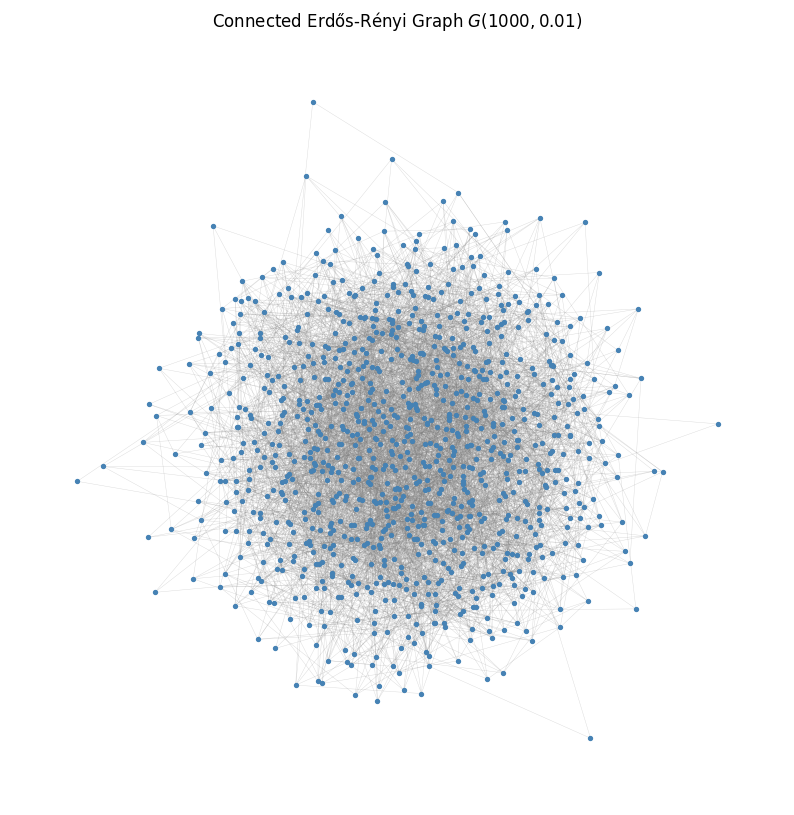

In [ ]:
plt.figure(figsize=(10, 10))

pos2 = nx.spring_layout(G2, seed=SEED2, iterations=30)

nx.draw_networkx_nodes(
    G2,
    pos2,
    node_size=8,
    node_color="steelblue"
)

nx.draw_networkx_edges(
    G2,
    pos2,
    width=0.3,
    alpha=0.3,
    edge_color="gray"
)

plt.title(r"Connected Erdős-Rényi Graph $G(1000,0.01)$")
plt.axis("off")
plt.show()

## Problem 2(a): Degree, Mean Degree, Mean Number of Edges, and Diameter

In [ ]:
# Degree of every node
degree_dict = dict(G2.degree())

# Maximum degree
max_degree = max(degree_dict.values())

# Nodes having maximum degree
max_degree_nodes = [
    node for node, degree in degree_dict.items()
    if degree == max_degree
]

# Mean degree
mean_degree = np.mean(list(degree_dict.values()))

# Actual number of edges
actual_edges = G2.number_of_edges()

# Theoretical values
theoretical_mean_degree = (N2 - 1) * p2
theoretical_mean_edges = p2 * N2 * (N2 - 1) / 2

print("Maximum degree:", max_degree)
print("Node(s) with maximum degree:", max_degree_nodes)

print("\nMean degree:")
print("Experimental:", mean_degree)
print("Theoretical:", theoretical_mean_degree)

print("\nNumber of edges:")
print("Experimental:", actual_edges)
print("Theoretical expected:", theoretical_mean_edges)

Maximum degree: 20
Node(s) with maximum degree: [457, 974]

Mean degree:
Experimental: 9.97
Theoretical: 9.99

Number of edges:
Experimental: 4985
Theoretical expected: 4995.0


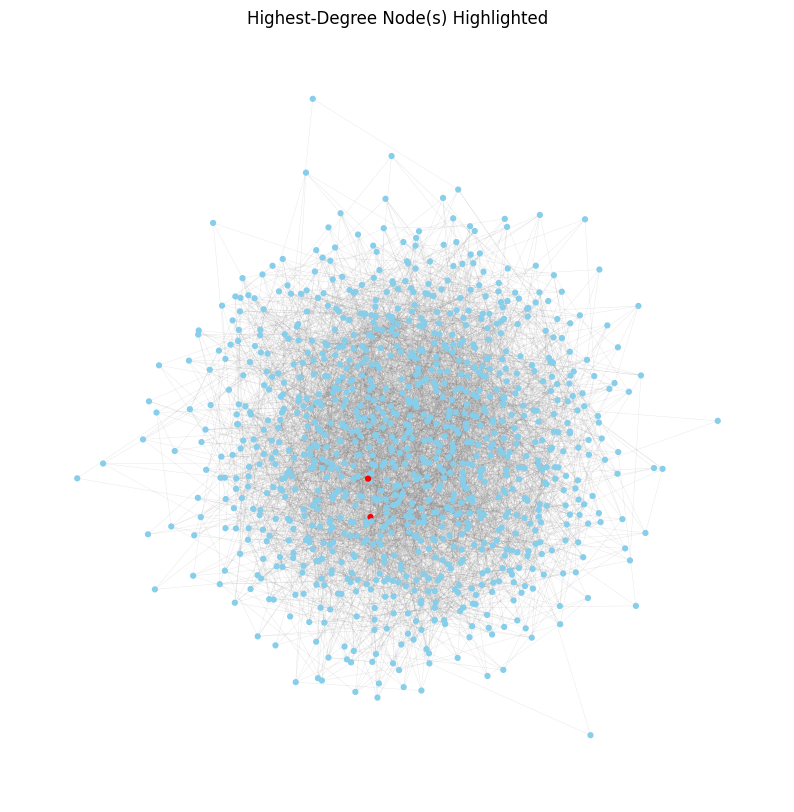

In [ ]:
plt.figure(figsize=(10, 10))

# Draw all nodes
node_colors = [
    "red" if node in max_degree_nodes else "skyblue"
    for node in G2.nodes()
]

nx.draw_networkx_nodes(
    G2,
    pos2,
    node_size=12,
    node_color=node_colors
)

nx.draw_networkx_edges(
    G2,
    pos2,
    width=0.3,
    alpha=0.2,
    edge_color="gray"
)

plt.title("Highest-Degree Node(s) Highlighted")
plt.axis("off")
plt.show()

### Graph Diameter

The diameter of a connected graph is the maximum shortest-path
distance between any pair of nodes:

$$
\operatorname{diam}(G)
=
\max_{u,v\in\mathcal{V}} d(u,v).
$$

We compute the diameter and identify one pair of nodes whose shortest
path has length equal to the diameter. The edges belonging to this
path are then highlighted.

In [ ]:
# Compute graph diameter
diameter = nx.diameter(G2)

print("Graph diameter:", diameter)

# Find one pair of nodes whose shortest path realizes the diameter
diameter_pair = None

for source in G2.nodes():
    lengths = nx.single_source_shortest_path_length(G2, source)
    
    for target, distance in lengths.items():
        if distance == diameter:
            diameter_pair = (source, target)
            break
    
    if diameter_pair is not None:
        break

print("Diameter pair:", diameter_pair)

# Get the diameter path
diameter_path = nx.shortest_path(
    G2,
    source=diameter_pair[0],
    target=diameter_pair[1]
)

# Convert path nodes into edges
diameter_edges = list(zip(diameter_path[:-1], diameter_path[1:]))

print("Diameter path:")
print(diameter_path)

Graph diameter: 6
Diameter pair: (407, 762)
Diameter path:
[407, 345, 35, 402, 529, 683, 762]


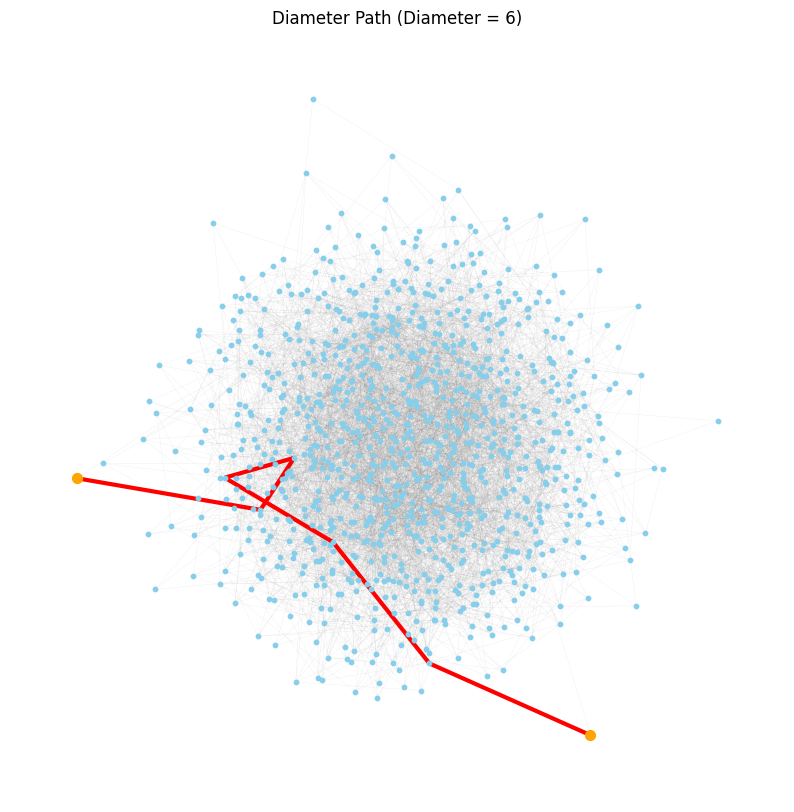

In [ ]:
plt.figure(figsize=(10, 10))

# Draw graph
nx.draw_networkx_nodes(
    G2,
    pos2,
    node_size=10,
    node_color="skyblue"
)

nx.draw_networkx_edges(
    G2,
    pos2,
    width=0.25,
    alpha=0.15,
    edge_color="gray"
)

# Highlight diameter edges
nx.draw_networkx_edges(
    G2,
    pos2,
    edgelist=diameter_edges,
    width=3,
    edge_color="red"
)

# Highlight diameter endpoints
nx.draw_networkx_nodes(
    G2,
    pos2,
    nodelist=list(diameter_pair),
    node_size=50,
    node_color="orange"
)

plt.title(f"Diameter Path (Diameter = {diameter})")
plt.axis("off")
plt.show()

## Problem 2(b): Shortest Path Between Two Random Nodes

In [ ]:
# Randomly select two distinct nodes
rng = np.random.default_rng(SEED2)

source, target = rng.choice(list(G2.nodes()), size=2, replace=False)

print("Source node:", source)
print("Target node:", target)

# Compute shortest path using Dijkstra's algorithm
shortest_path = nx.shortest_path(
    G2,
    source=source,
    target=target,
    method="dijkstra"
)

shortest_distance = len(shortest_path) - 1

print("Shortest path:")
print(shortest_path)

print("\nShortest path length:", shortest_distance)

# Convert path into edges
shortest_path_edges = list(
    zip(shortest_path[:-1], shortest_path[1:])
)

Source node: 89
Target node: 773
Shortest path:
[np.int64(89), 380, np.int64(773)]

Shortest path length: 2


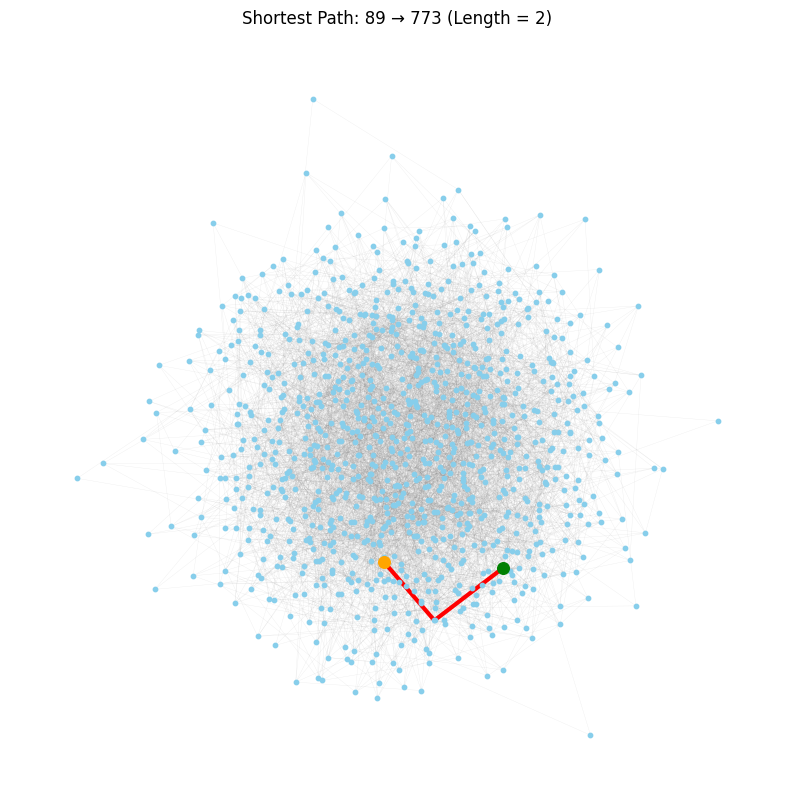

In [ ]:
plt.figure(figsize=(10, 10))

# Draw all nodes
nx.draw_networkx_nodes(
    G2,
    pos2,
    node_size=10,
    node_color="skyblue"
)

# Draw all edges
nx.draw_networkx_edges(
    G2,
    pos2,
    width=0.25,
    alpha=0.15,
    edge_color="gray"
)

# Highlight shortest path
nx.draw_networkx_edges(
    G2,
    pos2,
    edgelist=shortest_path_edges,
    width=3,
    edge_color="red"
)

# Highlight source and target
nx.draw_networkx_nodes(
    G2,
    pos2,
    nodelist=[source],
    node_size=70,
    node_color="green"
)

nx.draw_networkx_nodes(
    G2,
    pos2,
    nodelist=[target],
    node_size=70,
    node_color="orange"
)

plt.title(
    f"Shortest Path: {source} → {target} "
    f"(Length = {shortest_distance})"
)

plt.axis("off")
plt.show()